<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
# 1. Imports

# 2. Load Data

# 3. Basic Understanding

# 4. Clean Data

# 5. Feature Engineering

# 6. Separate X and y

# 7. Train-Test Split

# 8. Identify Numerical/Categorical Columns

# 9. Numerical Pipeline
#    Imputer → Scaler

# 10. Categorical Pipeline
#     Imputer → Encoder

# 11. ColumnTransformer

# 12. Final Pipeline
#     Preprocessor → Model

# 13. Fit

# 14. Predict

# 15. Evaluate

# 16. Cross Validation

# 17. Hyperparameter Tuning

# 18. Final Test Evaluation

# 19. Save Pipeline

# 20. Deployment

In [61]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

In [62]:
df=pd.read_csv('/content/sample_data/california_housing_train.csv').head(1000)
df.head(5)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           1000 non-null   float64
 1   latitude            1000 non-null   float64
 2   housing_median_age  1000 non-null   float64
 3   total_rooms         1000 non-null   float64
 4   total_bedrooms      1000 non-null   float64
 5   population          1000 non-null   float64
 6   households          1000 non-null   float64
 7   median_income       1000 non-null   float64
 8   median_house_value  1000 non-null   float64
dtypes: float64(9)
memory usage: 70.4 KB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-116.709970,33.178530,20.825000,3212.465000,651.963000,1579.355000,558.029000,3.422499,143689.602000
std,0.572927,0.603853,9.301123,2634.557551,536.881431,1167.885867,431.297776,1.537552,72594.233447
min,-117.100000,32.540000,2.000000,42.000000,10.000000,9.000000,3.000000,0.499900,14999.000000
25%,-117.060000,32.747500,15.000000,1593.500000,317.000000,816.000000,283.750000,2.264525,93200.000000
50%,-116.990000,32.850000,19.000000,2523.000000,511.000000,1305.500000,452.500000,3.132150,134050.000000
75%,-116.520000,33.710000,28.000000,3912.750000,788.250000,1997.750000,691.750000,4.221325,170850.000000
max,-114.310000,36.400000,52.000000,19107.000000,3923.000000,7985.000000,3232.000000,10.618600,500001.000000


In [63]:

df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [64]:
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns


In [66]:
sc=StandardScaler()

preprocessing=ColumnTransformer(
    transformers=[
        ("num",Pipeline(steps=[
            ("imputer",SimpleImputer(strategy="mean")),
            ("scaler",StandardScaler())
        ]),num_cols),

    ]
)
clf=Pipeline(steps=[
    ("preprocessor",preprocessing),
    ("classifier",LinearRegression())
])
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)




0.6163354905375085
30923.32091261948
2387525097.2919884


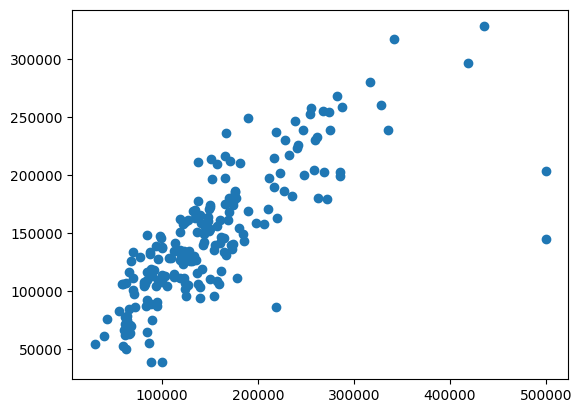

In [67]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()

In [68]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(score)
print("Mean R²:", score.mean())

[-0.37845857  0.51572517  0.65682383  0.68170276  0.52419667]
Mean R²: 0.3999979727970829


In [69]:
print("Train R²:", clf.score(X_train, y_train))
print("Test R²:", clf.score(X_test, y_test))

Train R²: 0.6897172920767445
Test R²: 0.6163354905375085


In [72]:
pipeline=Pipeline(steps=[
    ("preprocessor",preprocessing),
    ("classifier",RandomForestClassifier())
])
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)

In [70]:
# pipeline=Pipeline(steps=[
#     ("preprocessor",preprocessing),
#     ("classifier",RandomForestClassifier())
# ])
# pipeline.fit(X_train,y_train)
# y_pred=pipeline.predict(X_test)
# print(accuracy_score(y_test,y_pred))
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "classifier__n_estimators": [100, 200, 300, 500],

#     "classifier__max_depth": [
#         None, 5, 10, 20, 30
#     ],

#     "classifier__min_samples_split": [
#         2, 5, 10
#     ],

#     "classifier__min_samples_leaf": [
#         1, 2, 4
#     ],

#     "classifier__max_features": [
#         "sqrt",
#         "log2",
#         None
#     ]
# }


# grid = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,
#     cv=5,
#     scoring="neg_root_mean_squared_error",
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train, y_train)

In [71]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,       # only 20 combinations
    cv=3,            # instead of 5
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object'))])),
                                             ('classifier',
                                              RandomForestClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [75]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

# Best model found by RandomizedSearchCV
best_model = random_search.best_estimator_

# Predictions on TEST data
y_pred = best_model.predict(X_test)

# R²
r2 = r2_score(y_test, y_pred)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = root_mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R² Score: 0.5670103953952376
MAE: 33991.01
RMSE: 51908.31053896862
